# Unsupervised Learning with K-Means Clustering

### Part 1

In [788]:
import pandas as pd

# import dataset
data_frame = pd.read_csv("data/heart.csv")

In [789]:
# first rows of dataset
print(data_frame.head(5))

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [790]:
# dataset shape (number of columns/rows)
print("number of columns:", data_frame.shape[1])
print("number of rows:", data_frame.shape[0])

number of columns: 14
number of rows: 1025


In [791]:
# column names and data types
print(data_frame.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [792]:
# remove target column
data_frame = data_frame.drop('target', axis=1)
print(data_frame.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
dtype: object


In [793]:
# compute statistics(mean / standard deviation / minimum / maximum)
# 1. mean
print("mean:\n", data_frame.mean())

mean:
 age          54.434146
sex           0.695610
cp            0.942439
trestbps    131.611707
chol        246.000000
fbs           0.149268
restecg       0.529756
thalach     149.114146
exang         0.336585
oldpeak       1.071512
slope         1.385366
ca            0.754146
thal          2.323902
dtype: float64


In [794]:
# 2. standard deviation
print("standard deviation:\n", data_frame.std())

standard deviation:
 age          9.072290
sex          0.460373
cp           1.029641
trestbps    17.516718
chol        51.592510
fbs          0.356527
restecg      0.527878
thalach     23.005724
exang        0.472772
oldpeak      1.175053
slope        0.617755
ca           1.030798
thal         0.620660
dtype: float64


In [795]:
# 3. minimum
print("minimum:\n", data_frame.min())

minimum:
 age          29.0
sex           0.0
cp            0.0
trestbps     94.0
chol        126.0
fbs           0.0
restecg       0.0
thalach      71.0
exang         0.0
oldpeak       0.0
slope         0.0
ca            0.0
thal          0.0
dtype: float64


In [796]:
# 3. minimum
print("maximum:\n", data_frame.max())

maximum:
 age          77.0
sex           1.0
cp            3.0
trestbps    200.0
chol        564.0
fbs           1.0
restecg       2.0
thalach     202.0
exang         1.0
oldpeak       6.2
slope         2.0
ca            4.0
thal          3.0
dtype: float64


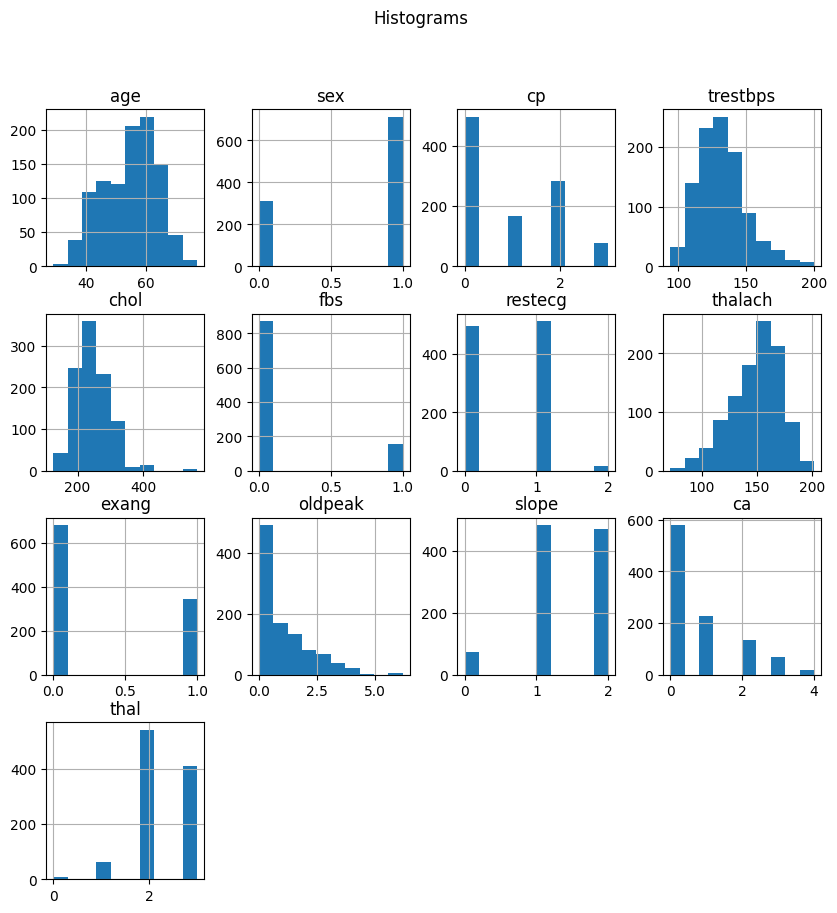

In [797]:
# analyze dataset distributions (histograms / box plots/ scatter plots)
import matplotlib.pyplot as plt

# 1. histograms
data_frame.hist(figsize=(10, 10))
plt.suptitle("Histograms")
plt.show()

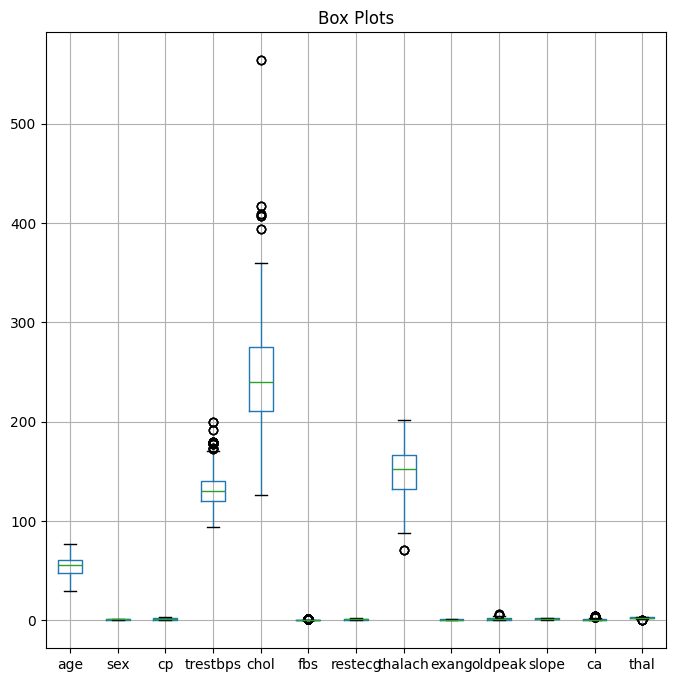

In [798]:
# 2. box plots 
data_frame.boxplot(figsize=(8, 8))
plt.title("Box Plots")
plt.show()

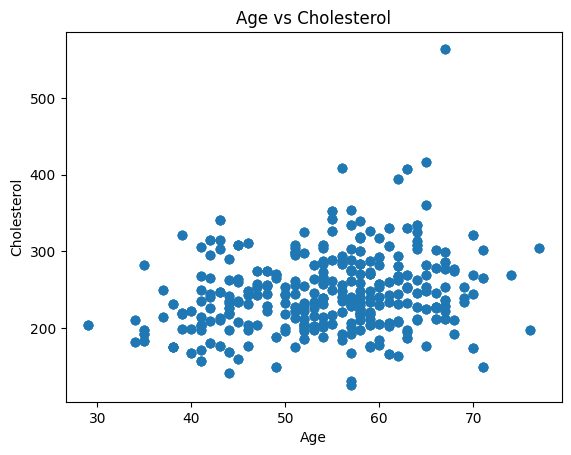

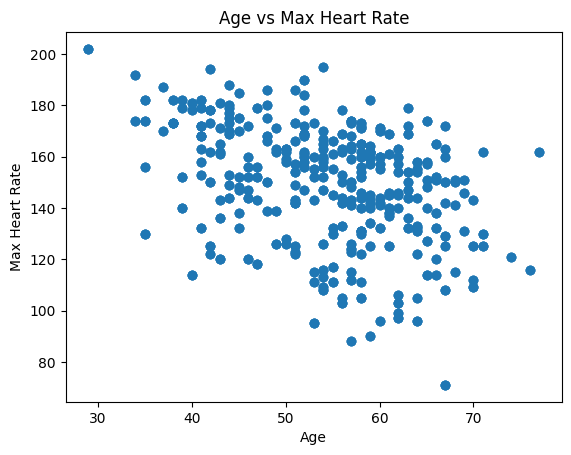

In [799]:
# 3. scatter plots (for selected features)
# age and cholesterol
plt.scatter(data_frame['age'], data_frame['chol'])
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.title('Age vs Cholesterol')
plt.show()

# age and max heart rate
plt.scatter(data_frame['age'], data_frame['thalach'])
plt.xlabel('Age')
plt.ylabel('Max Heart Rate')
plt.title('Age vs Max Heart Rate')
plt.show()

In [800]:
# identify missing values
print("missing values:\n", data_frame.isnull().sum())

# remove missing values
data_frame = data_frame.dropna()

missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


In [801]:
# irrelevant columns
# According to the data frame columns, there are no irrelevant columns; all columns are suitable for unsupervised learning.

In [802]:
# check for duplicates
print("Number of duplicate rows:", data_frame.duplicated().sum())

print("number of rows before: ", data_frame.shape[0])

# remove duplicate rows
data_frame = data_frame.drop_duplicates()
print("Doublons supprimés")

print("number of rows after: ", data_frame.shape[0])

Number of duplicate rows: 723
number of rows before:  1025
Doublons supprimés
number of rows after:  302


In [803]:
# encode categorical variables ( using the one hot encoding )
# (column with values A, B, C becomes three columns: A, B, C with 0/1 values)
data_frame = pd.get_dummies(data_frame, drop_first=True)
print("encoded categorical variables")
print("current columns:", data_frame.columns)

encoded categorical variables
current columns: Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')


In [804]:
# select the features to be used for clustering (numerical values)
features = data_frame
print("features for clustering:", features.shape[1])

features for clustering: 13


In [805]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# standardize numerical features
standard_scaler = StandardScaler()
features_scaled = standard_scaler.fit_transform(features)
print("features standardized, shape:", features_scaled.shape)

# normalize numerical features
normalize_scaler = MinMaxScaler()
features_normalized = normalize_scaler.fit_transform(features)
print("features normalized, shape:", features_normalized.shape)

features standardized, shape: (302, 13)
features normalized, shape: (302, 13)


### Part 2

In [806]:
from sklearn.model_selection import train_test_split

# split the dataset into a training set (80%) and a test set(20%)
x_train, x_test = train_test_split(features_scaled, test_size=0.2)
print("train shape", x_train.shape)
print("test shape", x_test.shape)

# splitting is useful in unsupervised learning to test cluster generalization and stability

train shape (241, 13)
test shape (61, 13)


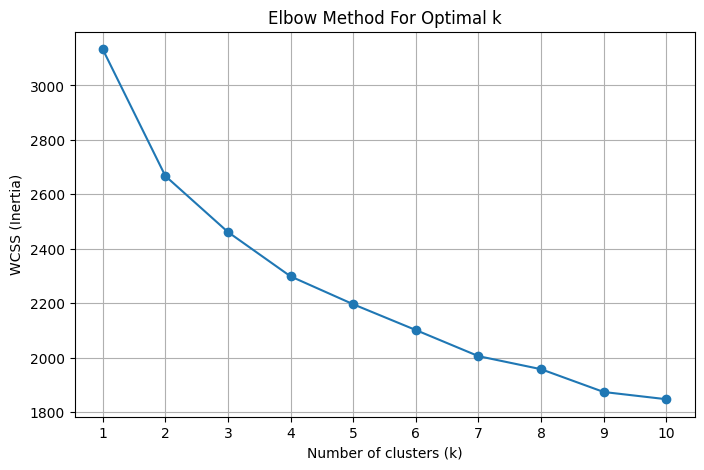

In [807]:
# apply Elbow Method to determine the optimal number of clusters k
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

wcss = []  # Within-cluster sum of squares
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [ ]:
# fit KMeans with the chosen number of clusters
k = 2  # k based on the Elbow Method result
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(x_train)

# obtain cluster labels for training and test data
train_labels = kmeans.predict(x_train)
test_labels = kmeans.predict(x_test)

print("cluster labels for training data:", train_labels)
print("cluster labels for test data:", test_labels)

Cluster labels for training data: [1 1 0 0 1 1 1 1 0 1 0 0 0 0 1 1 0 0 1 0 0 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 1
 0 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 0
 0 1 1 0 1 0 1 1 0 0 0 0 1 0 1 1 0 1 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 1 0 1
 0 1 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0
 0 0 1 0 1 1 1 0 0 1 1 1 1 1 0 0 1 0 1 0 0 1 1 0 1 1 1 0 1 1 0 1 0 1 1 1 1
 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 0 0 0 1 1 0 0 0 1 1 1 0 1 0 1 1 0 0 0 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 1]
Cluster labels for test data: [1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 0 0 1 1 0 0 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 0 0 0 1 0 1 1 1 0 0 1 1 0 1 1 0 0 0 1 0 1 0]


In [ ]:
# display the cluster centers
print("cluster centers:\n", kmeans.cluster_centers_)

Cluster centers (centroids):
 [[ 0.40012875  0.15826113 -0.66435418  0.23487012  0.08754508  0.10401688
  -0.00615866 -0.76584105  0.83745538  0.72000054 -0.66473308  0.52298619
   0.47398203]
 [-0.24939594 -0.07936795  0.38600526 -0.06270132 -0.05500407 -0.03797512
   0.05398142  0.50582358 -0.49218595 -0.34147486  0.31888906 -0.33619001
  -0.21882719]]


In [810]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.preprocessing import StandardScaler

# # fonctions définie pour 2) affichage du info du dataset
# def show_number_columns_rows(data_frame):
#     print("-------------------------")
#     print("number of columns:", data_frame.shape[1])
#     print("number of rows:", data_frame.shape[0])
#     print("-------------------------")

# def show_columns_types(data_frame):
#     print("-------------------------")
#     print("COLUMN : TYPE")
#     for column in data_frame.columns:
#         print(column, " : ", data_frame.dtypes[column])
#     print("-------------------------")

# # 1) import dataset
#  # import heart.csv

# # 2) afficher info du dataset
# show_number_columns_rows(data_frame)
# show_columns_types(data_frame)
# print(data_frame.head(10)) # on affiche les 10 premiers tuples

# # 3) supression de la column target
# data_frame = data_frame.drop('target', axis=1)

# # 4) calcule du mean , varience , min ...etc pour chaque column
# print(data_frame.describe()) # on utilise cette fonction describe() qui calcule pour chaque colonne mean , varience ..etc.

# # 5) analyse des distributions et les visualiser

# # histogrammes
# data_frame.hist(figsize=(12, 10))
# plt.suptitle("Histograms")
# plt.show()

# # box plots
# data_frame.boxplot(figsize=(12, 8))
# plt.title("Box Plots")
# plt.show()

# # scatter plots (on a choisir quelque features)
# plt.scatter(data_frame['age'], data_frame['chol']) #on compare le l'age avec le cholesterol du chaque patient
# plt.xlabel('Age')
# plt.ylabel('Cholesterol')
# plt.title('Age vs Cholesterol')
# plt.show()

# plt.scatter(data_frame['age'], data_frame['thalach']) #l'age avec le max heart rate
# plt.xlabel('Age')
# plt.ylabel('Max Heart Rate')
# plt.title('Age vs Max Heart Rate')
# plt.show()

# # 6) missing values
# print("- Missing values per column:")
# print(data_frame.isnull().sum())
# data_frame = data_frame.dropna() # supprimer lignes avec missing

# # 7) colonnes non pertinentes
# # d'aprés les column du data_frame il n'ya pas une colonne non pertinente, toutes les colonnes sont correcte pour unsupervised learning

# # 8) les doublons
# print("- Number of duplicate rows:", data_frame.duplicated().sum())
# data_frame = data_frame.drop_duplicates()
# print("- Doublons supprimés. Data Current Shape:")
# show_number_columns_rows(data_frame)

# # 9) encoder variables catégorielles
# data_frame = pd.get_dummies(data_frame, drop_first=True)
# print("- Variables catégorielles encodées. \n- Current columns:", data_frame.columns)

# # 10) selection des features pour clustering
# features = data_frame
# print("- Features pour clustering:", features.shape[1])

# # 11) normalisation / standardisation
# scaler = StandardScaler()
# features_scaled = scaler.fit_transform(features)
# print("- Features standardisées. Shape:")
# show_number_columns_rows(features_scaled)





In [811]:
# from sklearn.model_selection import train_test_split

# ## Split the dataset into training and test sets

# # In unsupervised learning, splitting the dataset into training and test sets can still be useful. Although there are no labels to predict, splitting allows us to:

# # - **Evaluate the stability and generalizability of clustering algorithms**: 
# # By fitting the clustering algorithm on the training set and then applying it to the test set, 
# # we can check if the clusters found are consistent and meaningful across different data samples.

# # - **Detect overfitting to specific data patterns**: 
# # If clusters found on the training set do not generalize to the test set, 
# # it may indicate that the clustering is too specific to the training data.

# # - **Validate preprocessing steps**: 
# # Splitting helps ensure that scaling, encoding, and other preprocessing 
# # steps are robust and do not leak information from the test set.

# # Below, we split the dataset into training (80%) and test (20%) sets.

# # Split the features into training and test sets (80% train, 20% test) before scaling to avoid data leakage
# X_train, X_test = train_test_split(features, test_size=0.2, random_state=42)

# # Scale the training and test sets separately
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# print(f"Training set shape: {X_train_scaled.shape}")
# print(f"Test set shape: {X_test_scaled.shape}")

